In [1]:
from __future__ import annotations

import logging
from pathlib import Path

import numpy as np
import typer

from qqe.GNN.dataset_builder import DataGenConfig, run_dataset_pipeline
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

In [19]:
backend = "pennylane"  # or "qiskit"
target = "SRE" # or EE
method = "fwht"
use_dask = True
dask_workers = 4
workers_memory_limit = "16GB"

output_file = f"../outputs/data"
n_bins = 50
families = "haar,random,quansistor,clifford"
n_seed = 10
qubits_min = 4
qubits_max = 8
n_layers_range = [1, 2, 4, 25, 50, 100]


In [20]:
selected_families = [f.strip() for f in families.split(",") if f.strip()]
qubits_values = np.arange(qubits_min, qubits_max + 1, 2)

In [21]:
output_dir = Path(output_file)


In [22]:
config = DataGenConfig(
    backend=backend,
    method=method,
    families=selected_families,
    qubits_values=qubits_values,
    layers_values=np.array(n_layers_range),
    n_seeds=n_seed,
    n_bins=n_bins,
    compute_sre=target == "SRE",
    compute_EE=target == "EE",
    representation="dense",
    use_dask=use_dask,
    dask_n_workers=dask_workers,
    dask_memory_per_worker=workers_memory_limit,
    output_dir=output_dir,
    max_configs=None,
)

In [23]:
run_dataset_pipeline(
    config=config,
    families=selected_families,
    qubits_values=qubits_values,
    layers_values=np.array(n_layers_range),
    n_seeds=n_seed,
    use_dask=use_dask,
    max_configs=None,
    dask_n_workers=dask_workers,
    dask_memory_per_worker=workers_memory_limit,
    )

Parallel dataset generation:  81%|████████  | 146/180 [00:15<00:03,  9.56it/s]


KeyboardInterrupt: 

In [24]:
import os

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import hashlib

from torch_geometric.data import Data, Dataset as PyGDataset

from qqe.GNN.physics_aware_NN import GNN, QuantumCircuitGraphDataset
import torch.nn as nn
from torch_geometric.loader import DataLoader

from qqe.GNN.training.utils import collect_files_path, cache_root_paths

In [25]:
def _plot_SRE_distribution(
    dataset,
    bins=30,
    value_range=None,
    density=True,
    show_mean=True,
    min_count=1,
    title="SRE frequency by number of qubits",
):
    grouped_sre = {}

    # -----------------------------
    # Collect SRE values by qubit count
    # -----------------------------
    for data in dataset:
        if not hasattr(data, "num_qubits"):
            continue
        if not hasattr(data, "y") or data.y is None:
            continue

        q = int(data.num_qubits)

        # robust extraction of scalar y
        y = data.y
        if torch.is_tensor(y):
            if y.numel() == 0:
                continue
            y_val = float(y.view(-1)[0].item())
        else:
            y_val = float(np.array(y).reshape(-1)[0])

        if not np.isfinite(y_val):
            continue

        grouped_sre.setdefault(q, []).append(y_val)

    # remove groups with too few points
    grouped_sre = {q: vals for q, vals in grouped_sre.items() if len(vals) >= min_count}

    if not grouped_sre:
        raise ValueError("No valid finite SRE values found in the dataset.")

    # -----------------------------
    # Determine histogram range
    # -----------------------------
    all_vals = np.concatenate([np.asarray(v, dtype=float) for v in grouped_sre.values()])
    if value_range is None:
        xmin = float(np.nanmin(all_vals))
        xmax = float(np.nanmax(all_vals))
        if xmin == xmax:
            xmin -= 0.5
            xmax += 0.5
        value_range = (xmin, xmax)

    bin_edges = np.linspace(value_range[0], value_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(9, 6))

    for q in sorted(grouped_sre):
        vals = np.array(grouped_sre[q])

        counts, _ = np.histogram(vals, bins=bin_edges)

        if density:
            freq = 100 * counts / counts.sum()
        else:
            freq = counts

        # plot curve and capture color
        line, = plt.plot(bin_centers, freq, label=f"{q} qubits")
        color = line.get_color()

        # plot mean with SAME color
        if show_mean:
            mean_val = vals.mean()
            plt.axvline(
                mean_val,
                linestyle="--",
                linewidth=1.5,
                color=color,
                alpha=0.9,
            )

            ymax = freq.max()
            plt.text(
                mean_val - 0.5,
                ymax + 0.5,
                f"{mean_val:.2f}",
                color=color,
                ha="center",
                fontsize=8,
            )

    plt.xlabel("Stabilizer Rényi Entropy")
    plt.ylabel("Frequency (%)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [26]:
global_feature_variant: str = "binned"
node_feature_variant: str | None = None
family_projection: str | None = None

Found 40000 dataset files for family 'clifford'


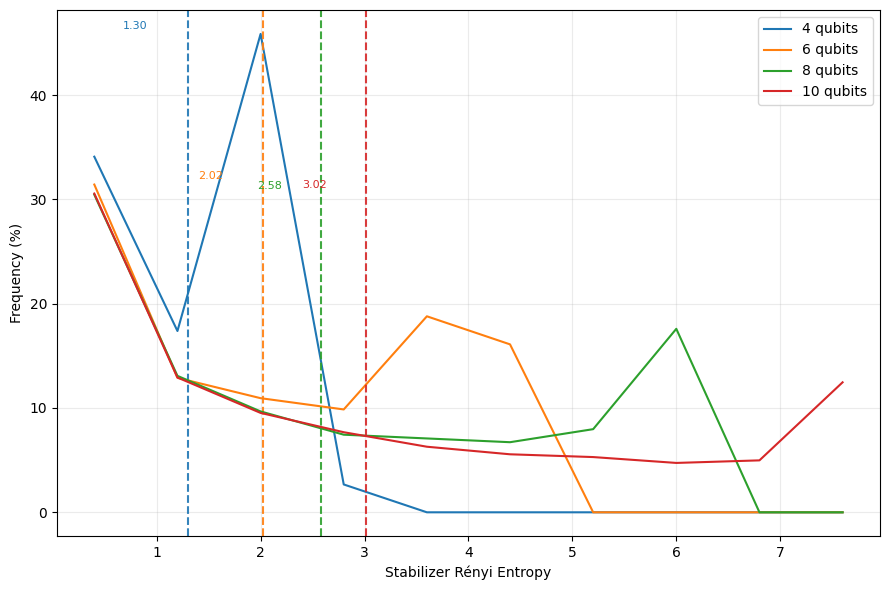

In [27]:
family = "clifford"
# family = None
dataset_paths = collect_files_path(output_file, family=family)
print(f"Found {len(dataset_paths)} dataset files for family '{family}'")
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#clifford
_plot_SRE_distribution(
    base_dataset,
    bins=10,
    value_range=(0, 8),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)

Found 40058 dataset files for family 'haar'


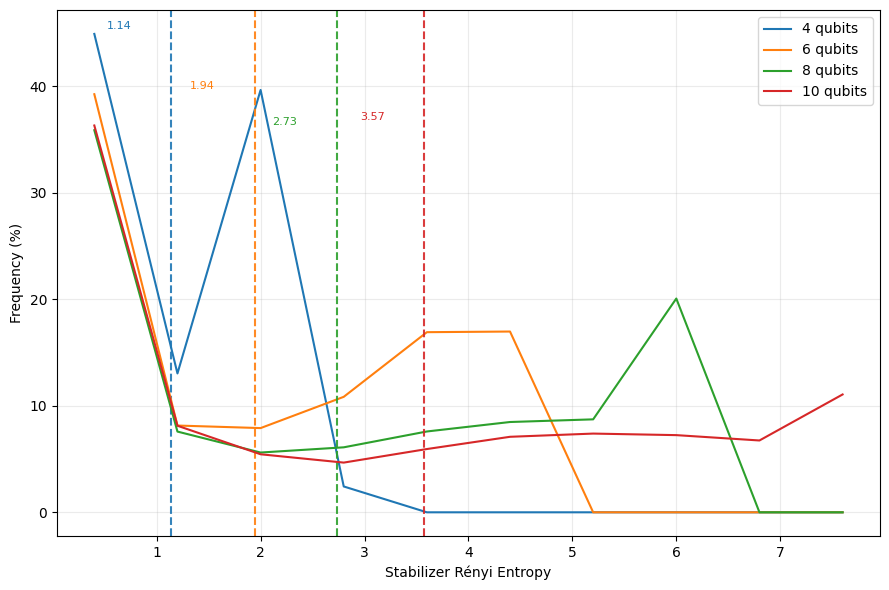

In [28]:
family = "haar"
# family = None
dataset_paths = collect_files_path(output_file, family=family)
print(f"Found {len(dataset_paths)} dataset files for family '{family}'")
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#haar
_plot_SRE_distribution(
    base_dataset,
    bins=10,
    value_range=(0, 8),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)

Found 40000 dataset files for family 'random'


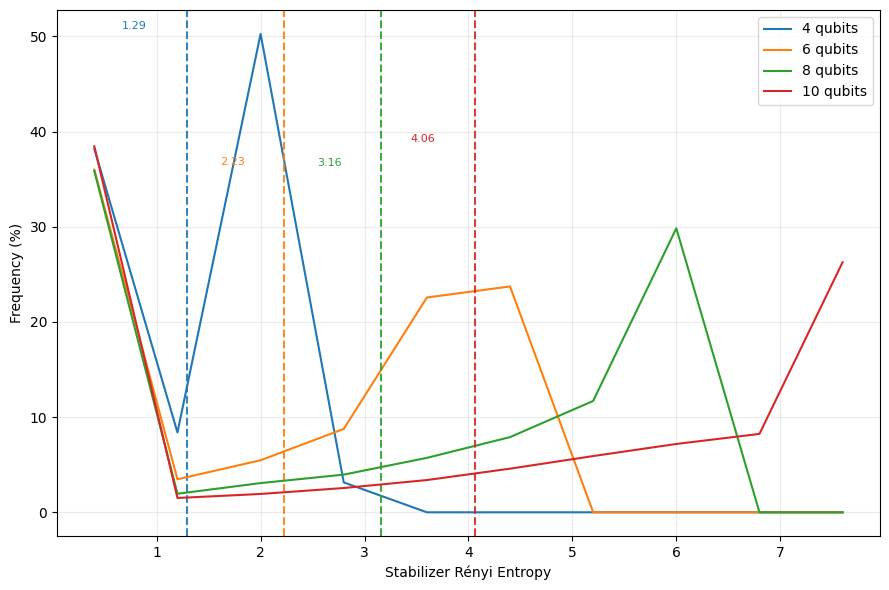

In [29]:
family = "random"
# family = None
dataset_paths = collect_files_path(output_file, family=family)
print(f"Found {len(dataset_paths)} dataset files for family '{family}'")
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#random
_plot_SRE_distribution(
    base_dataset,
    bins=10,
    value_range=(0, 8),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)

Found 37624 dataset files for family 'quansistor'


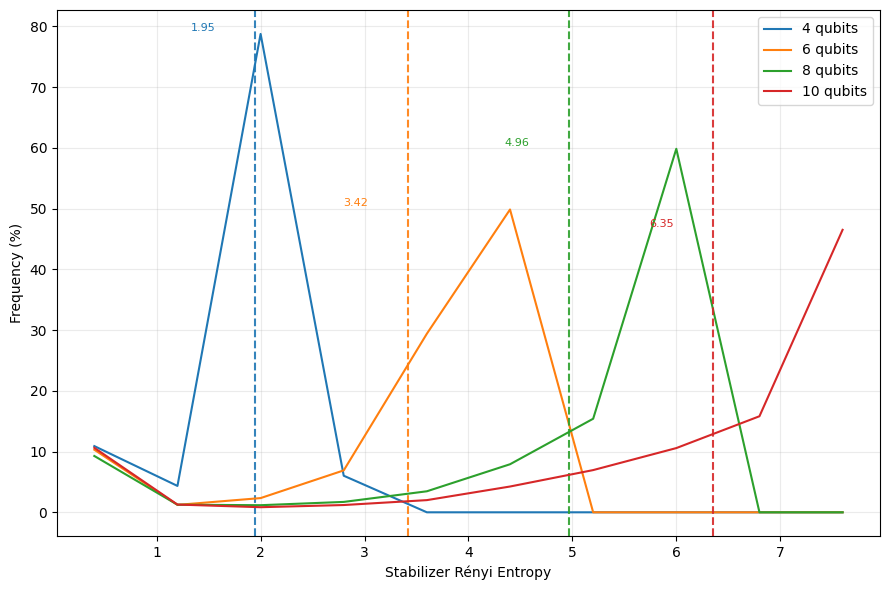

In [30]:
family = "quansistor"
# family = None
dataset_paths = collect_files_path(output_file, family=family)
print(f"Found {len(dataset_paths)} dataset files for family '{family}'")
suffix = (
    f"{global_feature_variant}"
    f"__backend_{node_feature_variant or 'none'}"
    f"_familyproj_{family_projection or 'none'}"
)
root = cache_root_paths(dataset_paths, suffix=suffix)

base_dataset = QuantumCircuitGraphDataset(
    root=root,
    pt_paths=dataset_paths,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_variant,
)

#quansistor
_plot_SRE_distribution(
    base_dataset,
    bins=10,
    value_range=(0, 8),
    density=True,
    show_mean=True,
    title=f"Random-circuit SRE distributions by qubit count ({family})",
)